<a href="https://colab.research.google.com/github/code-with-shahin/Band-Name-Generator/blob/master/Master_LFB_Response_Time_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. London Fire Brigade (LFB) Response Time Project

**1.1 Set up the Project Goal**

The goal is to analyse how quickly the LFB responds to incidents.

We will mainly analyse:

- **Mobilisation time**: how long it takes to dispatch a fire engine.
- **Response time:** how long it takes to arrive at the incident

Key questions we might answer:

- How has response time changed over the years?
- Which boroughs have the longest response times?
- Which incident types take longer to respond to?
- Are response times improving or worsening?

**1.2. Analyse Two Datasets**

Dataset 1. LFB Incident Records (Saskia)

Contains: (incident details)

- Incident date
- Location (borough)
- Incident type
- Property type
- Number of vehicles (pumps)

Dataset 2. LFB Mobilisation Records (Shahin)

Contains: (response time analysis)

- Fire engine dispatched
- Station location
- mobilisation time
- arrival time
- response time

# 2. Structure of the Project

**Step 1. Data Exploration**

- Loading the datasets.
- Checking structure/columns.
- Checking data types
- Checking missing values.

**Step 2. Data Cleaning**

- Converting dates/times
- Removing missing response times

**Step 3. Merge the Datasets**

To combine incident information + mobilisation times using:

- Primary Key: Incident Number
- Foreign Keys: Location, Incident type, Response time, etc.

**Step 4. Data Visualization**

We can use either Python (Matplotlib / Seaborn) or Power BI (Report view).

**Some DataViz suggestions:**

- Response Time over Years
- Response Time by Borough
- Incident Types

**Step 5. Data Analysis Suggestions**

**1️. Response time trend:**

Is response time increasing or decreasing since 2009?

**2.Borough comparison:**

Which boroughs have the fastest/slowest response?

**3️. Incident type comparison (max/min):**

Example types: Fire, False alarm, Special service…

#

# Import Packages

In [ ]:
# Importing basic Python libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import os
%matplotlib inline


#

# Import Data

In [ ]:
# mount Google Drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
# find file path
import os

print("Incident Data:")
print(os.listdir('/content/drive/MyDrive/Project London Fire Brigade/Incident Data'))

print("\nMobilisation Data:")
print(os.listdir('/content/drive/MyDrive/Project London Fire Brigade/Mobilisation Data'))

Incident Data:
['LFB Incident data from 2024 onwards (1).xlsx', 'LFB Incident data from 2018 - 2023.xlsx', 'LFB Incident data from 2009 - 2017.csv', 'Metadata.xlsx', 'incidents_2015_2023.csv']

Mobilisation Data:
['LFB Mobilisation data from 2025.csv', 'LFB Mobilisation data from 2021 - 2024.csv', 'LFB Mobilisation data from 2015 - 2020.xlsx', 'LFB Mobilisation data from January 2009 - 2014.xlsx', 'mobilisation_agg_2015_2023.csv', 'Mobilisations Metadata (1).xlsx', 'mobilisation_2015_2023.csv']


In [ ]:

import pandas as pd
import os

# Base path to Google Drive project folder
BASE = '/content/drive/MyDrive/Project London Fire Brigade/'

# Subfolders containing the datasets
incident_path = BASE + 'Incident Data/'
mobilisation_path = BASE + 'Mobilisation Data/'


# Function to automatically load CSV or Excel files
def load_file(path):
    """
    Loads a file depending on its format (CSV or Excel).
    """
    if path.endswith('.csv'):
        # low_memory=False avoids dtype warnings for large files
        return pd.read_csv(path, low_memory=False)
    elif path.endswith('.xlsx') or path.endswith('.xls'):
        return pd.read_excel(path)
    else:
        raise ValueError(f"Unsupported file format: {path}")


# -------------------------
# LOAD INCIDENT DATA
# -------------------------

# List of incident data files (excluding metadata)
incident_files = [
    'LFB Incident data from 2024 onwards (1).xlsx',
    'LFB Incident data from 2018 - 2023.xlsx',
    'LFB Incident data from 2009 - 2017.csv'
]

# Store all datasets in a list
df_incidents_list = []

# Loop through files and load them
for file in incident_files:
    print(f"Loading Incident file: {file}")

    df = load_file(incident_path + file)

    # Add column to track data source
    df['source_file'] = file

    df_incidents_list.append(df)

# Combine all incident datasets into one DataFrame
incidents = pd.concat(df_incidents_list, ignore_index=True)

print("Incidents loaded:", incidents.shape)


# -------------------------
# LOAD MOBILISATION DATA
# -------------------------

# List of mobilisation data files (excluding metadata)
mobilisation_files = [
    'LFB Mobilisation data from 2025.csv',
    'LFB Mobilisation data from 2021 - 2024.csv',
    'LFB Mobilisation data from 2015 - 2020.xlsx',
    'LFB Mobilisation data from January 2009 - 2014.xlsx'
]

df_mobilisation_list = []

# Loop through files and load them
for file in mobilisation_files:
    print(f"Loading Mobilisation file: {file}")

    df = load_file(mobilisation_path + file)

    # Add column to track source file
    df['source_file'] = file

    df_mobilisation_list.append(df)

# Combine all mobilisation datasets
mobilisation = pd.concat(df_mobilisation_list, ignore_index=True)

print("Mobilisation loaded:", mobilisation.shape)

df = pd.DataFrame(mobilisation)

# Preview data
display(incidents.head())
display(mobilisation.head())

Loading Incident file: LFB Incident data from 2024 onwards (1).xlsx
Loading Incident file: LFB Incident data from 2018 - 2023.xlsx
Loading Incident file: LFB Incident data from 2009 - 2017.csv
Incidents loaded: (1952560, 40)
Loading Mobilisation file: LFB Mobilisation data from 2025.csv
Loading Mobilisation file: LFB Mobilisation data from 2021 - 2024.csv
Loading Mobilisation file: LFB Mobilisation data from 2015 - 2020.xlsx
Loading Mobilisation file: LFB Mobilisation data from January 2009 - 2014.xlsx
Mobilisation loaded: (2753920, 25)


,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls,source_file
0,000002-01012024,2024-01-01 00:00:00,2024,00:00:43,0,Special Service,Special Service,Advice Only,Dwelling,Unlicensed House in Multiple Occupation - Up t...,...,Stratford,289.0,Stratford,2.0,2.0,2,60,388,1.0,LFB Incident data from 2024 onwards (1).xlsx
1,000003-01012024,2024-01-01 00:00:00,2024,00:01:11,0,Special Service,Special Service,No action (not false alarm),Dwelling,Purpose Built Flats/Maisonettes - 10 or more s...,...,Shoreditch,NaN,NaN,1.0,1.0,1,60,388,1.0,LFB Incident data from 2024 onwards (1).xlsx
2,000007-01012024,2024-01-01 00:00:00,2024,00:04:21,0,False Alarm,False alarm - Good intent,NaN,Outdoor,Loose refuse,...,Lambeth,NaN,NaN,1.0,1.0,1,60,388,1.0,LFB Incident data from 2024 onwards (1).xlsx
3,000010-01012024,2024-01-01 00:00:00,2024,00:05:40,0,Special Service,Special Service,Lift Release,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,...,NaN,NaN,NaN,1.0,1.0,1,60,388,1.0,LFB Incident data from 2024 onwards (1).xlsx
4,000011-01012024,2024-01-01 00:00:00,2024,00:06:32,0,Special Service,Special Service,Effecting entry/exit,Dwelling,Purpose Built Flats/Maisonettes - 10 or more s...,...,Lee Green,NaN,NaN,1.0,1.0,1,60,388,2.0,LFB Incident data from 2024 onwards (1).xlsx


,IncidentNumber,CalYear,BoroughName,WardName,HourOfCall,ResourceMobilisationId,Resource_Code,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,...,DateAndTimeReturned,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,PlusCode_Code,PlusCode_Description,DelayCodeId,DelayCode_Description,source_file
0,000004-01012025,2025,HAMMERSMITH AND FULHAM,FULHAM REACH,0,6862256,H331,2,01/01/2025 00:02,01/01/2025 00:07,...,NaN,H33,Wandsworth,Home Station,2,Initial,Initial Mobilisation,12.0,Not held up,LFB Mobilisation data from 2025.csv
1,000004-01012025,2025,HAMMERSMITH AND FULHAM,FULHAM REACH,0,6862257,G261,1,01/01/2025 00:02,01/01/2025 00:02,...,NaN,G36,Hammersmith,Other Station,1,Initial,Initial Mobilisation,12.0,Not held up,LFB Mobilisation data from 2025.csv
2,000005-01012025,2025,MERTON,WEST BARNES,0,6862259,H401,1,01/01/2025 00:03,01/01/2025 00:04,...,NaN,H40,New Malden,Home Station,1,Initial,Initial Mobilisation,NaN,NaN,LFB Mobilisation data from 2025.csv
3,000006-01012025,2025,CROYDON,PURLEY OAKS & RIDDLESDOWN,0,6862260,H291,1,01/01/2025 00:04,01/01/2025 00:06,...,NaN,H29,Purley,Home Station,1,Initial,Initial Mobilisation,NaN,NaN,LFB Mobilisation data from 2025.csv
4,000007-01012025,2025,BARNET,BURNT OAK,0,6862261,G222,1,01/01/2025 00:05,01/01/2025 00:06,...,NaN,G22,Stanmore,Home Station,1,Initial,Initial Mobilisation,NaN,NaN,LFB Mobilisation data from 2025.csv


#

# Summary Tables

## Incidents

In [ ]:
# Creating summary table:

# Making sure pandas doesn't wrap columns:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)       # Set display width

summary = pd.DataFrame({
    "Column Name": incidents.columns,
    "Data Type": incidents.dtypes.values,
    "Missing Values": incidents.isnull().sum().values,
    "Missing %": incidents.isnull().mean().values * 100,
    "Unique Values": incidents.nunique().values
})

display(summary)

,Column Name,Data Type,Missing Values,Missing %,Unique Values
0,IncidentNumber,object,0,0.000000,1952560
1,DateOfCall,object,0,0.000000,6266
2,CalYear,int64,0,0.000000,18
3,TimeOfCall,object,0,0.000000,172488
4,HourOfCall,int64,0,0.000000,24
5,IncidentGroup,object,54,0.002766,3
6,StopCodeDescription,object,0,0.000000,12
7,SpecialServiceType,object,1301866,66.674827,21
8,PropertyCategory,object,11,0.000563,9
9,PropertyType,object,11,0.000563,292


## Mobilisation

In [ ]:
# Creating summary table:

# Making sure pandas doesn't wrap columns:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)       # Set display width

summary = pd.DataFrame({
    "Column Name": mobilisation.columns,
    "Data Type": mobilisation.dtypes.values,
    "Missing Values": mobilisation.isnull().sum().values,
    "Missing %": mobilisation.isnull().mean().values * 100,
    "Unique Values": mobilisation.nunique().values
})

display(summary)

,Column Name,Data Type,Missing Values,Missing %,Unique Values
0,IncidentNumber,object,0,0.000000,1814670
1,CalYear,int64,0,0.000000,18
2,BoroughName,object,1789077,64.964741,37
3,WardName,object,1790095,65.001707,1283
4,HourOfCall,int64,0,0.000000,24
5,ResourceMobilisationId,int64,0,0.000000,2748578
6,Resource_Code,object,0,0.000000,187
7,PerformanceReporting,object,0,0.000000,5
8,DateAndTimeMobilised,object,0,0.000000,1767390
9,DateAndTimeMobile,object,29636,1.076139,2394986


#

# Pre-Prep for Joining Data

Applying some pre-preparations to be able to join both datasets.

# Incident Records

- only years from 2015 to 2023
- drop redundant columns


### set filter

In [ ]:
# filter only years from 2015 to 2023
incidents = incidents.loc[(incidents["CalYear"] >= 2015) & (incidents["CalYear"] <= 2023)]

### drop columns

In [ ]:
# show column names
incidents.columns

Index(['IncidentNumber', 'DateOfCall', 'CalYear', 'TimeOfCall', 'HourOfCall', 'IncidentGroup', 'StopCodeDescription', 'SpecialServiceType', 'PropertyCategory', 'PropertyType', 'AddressQualifier', 'Postcode_full', 'Postcode_district', 'UPRN', 'USRN', 'IncGeo_BoroughCode', 'IncGeo_BoroughName', 'ProperCase', 'IncGeo_WardCode', 'IncGeo_WardName', 'IncGeo_WardNameNew', 'Easting_m', 'Northing_m', 'Easting_rounded', 'Northing_rounded', 'Latitude', 'Longitude', 'FRS', 'IncidentStationGround', 'FirstPumpArriving_AttendanceTime', 'FirstPumpArriving_DeployedFromStation', 'SecondPumpArriving_AttendanceTime', 'SecondPumpArriving_DeployedFromStation', 'NumStationsWithPumpsAttending', 'NumPumpsAttending', 'PumpCount', 'PumpMinutesRounded', 'Notional Cost (£)', 'NumCalls', 'source_file'], dtype='object')

In [ ]:
# Drop redundant columns
incidents = incidents.drop([
    "TimeOfCall",
    "SpecialServiceType",
    "AddressQualifier",
    "Postcode_full",
    "UPRN",
    "USRN",
    "IncGeo_BoroughCode",
    "ProperCase",
    "IncGeo_WardName",
    "IncGeo_WardCode",
    "Easting_m",
    "Northing_m",
    "Latitude",
    "Longitude",
    "FRS",
    "NumStationsWithPumpsAttending",
    "NumPumpsAttending",
    "SecondPumpArriving_AttendanceTime",
    "SecondPumpArriving_DeployedFromStation",

], axis=1)

# display shape
incidents.shape

(976818, 21)

### save file

In [ ]:
# save data set
incidents.to_csv("/content/drive/MyDrive/Project London Fire Brigade/Incident Data/incidents_2015_2023.csv", index = False)

# Mobilization Records
- only years from 2015 to 2023
- only rows with PumpOrder == 1

### set filter

In [ ]:
# filter only years between 2015 and 2023
mobilisation = mobilisation.loc[(mobilisation["CalYear"] >= 2015) & (mobilisation["CalYear"] <= 2023)]


In [ ]:
# filter only first pump
mobilisation = mobilisation.sort_values(
    ["IncidentNumber", "PumpOrder"]
).drop_duplicates("IncidentNumber")

### drop columns

In [ ]:
# drop redundant columns
mobilisation = mobilisation.drop([
    "Resource_Code",
    "AttendanceTimeSeconds",
    "DateAndTimeLeft",
    "DateAndTimeReturned",
    "DeployedFromStation_Code",
    "PlusCode_Code",
    "BoroughName",
    "WardName"
], axis=1)

# display shape
mobilisation.shape

(921766, 17)

### save file

In [ ]:
# save data set
mobilisation.to_csv("/content/drive/MyDrive/Project London Fire Brigade/Mobilisation Data/mobilisation_2015_2023.csv", index = False)

#

# Joining Data-Sets

In [ ]:
# merge incidents and mobilisation (pump order == 1)
df_merged = incidents.merge(mobilisation, on="IncidentNumber", how = "left")

df_merged.shape

(976818, 37)

In [ ]:
# double check for duplicates
df_merged["IncidentNumber"].duplicated().sum()

np.int64(0)

# Save Merged Data

In [ ]:
# save data set
df_merged.to_csv("/content/drive/MyDrive/Project London Fire Brigade/Merged Data/df_merged_2015_2023.csv", index = False)

#

# Load Merged Data

From this step on, we can work with the merged data and don´t need to run the code above. This will also speed up the loading time by a good amount.

In [ ]:
# Importing basic Python libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import os
%matplotlib inline

# mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# load df_merged
path = "/content/drive/MyDrive/Project London Fire Brigade/Merged Data/df_merged_2015_2023.csv"
df = pd.read_csv(path, low_memory=False)

# display shape
df.shape

Mounted at /content/drive


(976818, 37)

In [ ]:
# Making sure pandas doesn't wrap columns:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)       # Set display width
df.head()


,IncidentNumber,DateOfCall,CalYear_x,HourOfCall_x,IncidentGroup,StopCodeDescription,PropertyCategory,PropertyType,Postcode_district,IncGeo_BoroughName,IncGeo_WardNameNew,Easting_rounded,Northing_rounded,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls,source_file_x,CalYear_y,HourOfCall_y,ResourceMobilisationId,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,TravelTimeSeconds,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,PlusCode_Description,DelayCodeId,DelayCode_Description,source_file_y
0,000008-01012018,2018-01-01 00:00:00,2018,0,False Alarm,AFA,Non Residential,Mosque,N2,BARNET,East Finchley,527150,189450,Finchley,348.0,Finchley,1,60,328,1.0,LFB Incident data from 2018 - 2023.xlsx,2018.0,0.0,5055153.0,1.0,2018-01-01 00:04:25,2018-01-01 00:05:38,2018-01-01 00:10:13,73.0,275.0,Finchley,Home Station,1.0,Initial Mobilisation,NaN,NaN,LFB Mobilisation data from 2015 - 2020.xlsx
1,000009-01012018,2018-01-01 00:00:00,2018,0,False Alarm,AFA,Non Residential,Pub/wine bar/bar,BR3,BROMLEY,Beckenham Town & Copers Cope,537450,169550,Beckenham,144.0,Beckenham,1,60,328,1.0,LFB Incident data from 2018 - 2023.xlsx,2018.0,0.0,5055154.0,1.0,2018-01-01 00:04:31,2018-01-01 00:05:23,2018-01-01 00:06:55,52.0,92.0,Beckenham,Home Station,1.0,Initial Mobilisation,NaN,NaN,LFB Mobilisation data from 2015 - 2020.xlsx
2,000010-01012018,2018-01-01 00:00:00,2018,0,Fire,Secondary Fire,Outdoor Structure,Common external bin storage area,N13,ENFIELD,Highfield,531950,193150,Edmonton,232.0,Southgate,1,60,328,1.0,LFB Incident data from 2018 - 2023.xlsx,2018.0,0.0,5055155.0,1.0,2018-01-01 00:04:34,2018-01-01 00:05:36,2018-01-01 00:08:26,62.0,170.0,Southgate,Home Station,1.0,Initial Mobilisation,NaN,NaN,LFB Mobilisation data from 2015 - 2020.xlsx
3,000011-01012018,2018-01-01 00:00:00,2018,0,Special Service,Special Service,Road Vehicle,Multiple Vehicles,EN1,ENFIELD,Carterhatch,534750,197450,Enfield,22.0,Enfield,1,60,328,1.0,LFB Incident data from 2018 - 2023.xlsx,2018.0,0.0,5055156.0,1.0,2018-01-01 00:04:58,2018-01-01 00:05:17,2018-01-01 00:05:20,19.0,3.0,Enfield,Home Station,1.0,Initial Mobilisation,NaN,NaN,LFB Mobilisation data from 2015 - 2020.xlsx
4,000014-01012018,2018-01-01 00:00:00,2018,0,Fire,Primary Fire,Road Vehicle,Car,E15,NEWHAM,Maryland,539450,185350,Stratford,241.0,Stratford,1,60,328,6.0,LFB Incident data from 2018 - 2023.xlsx,2018.0,0.0,5055157.0,1.0,2018-01-01 00:07:47,2018-01-01 00:08:58,2018-01-01 00:11:48,71.0,170.0,Stratford,Home Station,1.0,Initial Mobilisation,NaN,NaN,LFB Mobilisation data from 2015 - 2020.xlsx


## Summary Table

In [ ]:
# create summary table

# define parameters for summary table
summary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Missing values": df.isna().sum().values,
    "Missing values in %": (df.isnull().sum().values) / len(df) * 100,
    "Unique values": df.nunique().values
})

# display number of rows and columns
rows, cols = df.shape

# display summary table
print("-------------------------")
print("Summary table:")
print("-------------------------\n")

print("Number of rows:", rows)
print("Number of columns:", cols)
print("\n-------------------------\n")
display(summary)

-------------------------
Summary table:
-------------------------

Number of rows: 976818
Number of columns: 37

-------------------------



,Column Name,Data Type,Missing values,Missing values in %,Unique values
0,IncidentNumber,object,0,0.000000,976818
1,DateOfCall,object,0,0.000000,3286
2,CalYear_x,int64,0,0.000000,9
3,HourOfCall_x,int64,0,0.000000,24
4,IncidentGroup,object,0,0.000000,3
5,StopCodeDescription,object,0,0.000000,10
6,PropertyCategory,object,0,0.000000,9
7,PropertyType,object,0,0.000000,287
8,Postcode_district,object,0,0.000000,309
9,IncGeo_BoroughName,object,0,0.000000,33


#

#

# Pre-Cleaning
The data set was further adjusted to meet our objective goals.
Therefor several columns were deleted and the filter was set to obtain our target boroughs.

## Drop Redundant Columns
There are several redundant columns after merging, which we will delete.

In [ ]:
# display columns to identify redundant columns
df.columns

Index(['IncidentNumber', 'DateOfCall', 'CalYear_x', 'HourOfCall_x',
       'IncidentGroup', 'StopCodeDescription', 'PropertyCategory',
       'PropertyType', 'Postcode_district', 'IncGeo_BoroughName',
       'IncGeo_WardNameNew', 'Easting_rounded', 'Northing_rounded',
       'IncidentStationGround', 'FirstPumpArriving_AttendanceTime',
       'FirstPumpArriving_DeployedFromStation', 'PumpCount',
       'PumpMinutesRounded', 'Notional Cost (£)', 'NumCalls', 'source_file_x',
       'CalYear_y', 'HourOfCall_y', 'ResourceMobilisationId',
       'PerformanceReporting', 'DateAndTimeMobilised', 'DateAndTimeMobile',
       'DateAndTimeArrived', 'TurnoutTimeSeconds', 'TravelTimeSeconds',
       'DeployedFromStation_Name', 'DeployedFromLocation', 'PumpOrder',
       'PlusCode_Description', 'DelayCodeId', 'DelayCode_Description',
       'source_file_y'],
      dtype='object')

In [ ]:
# delete all redundant columns after merging
cols_to_drop = [
    "source_file_x", "source_file_y", # columns were created while loading full data for better debugging but are now redundant
    'CalYear_y', 'HourOfCall_y',      # dupliactes of second dataset
]

df = df.drop(columns=cols_to_drop)

In [ ]:
# display shape
df.shape

(976818, 33)

## Filter Boroughs
For our analyses only the boroughs of Westminster and Havering are considered.

In [ ]:
df = df.loc[(df["IncGeo_BoroughName"] == "WESTMINSTER") | (df["IncGeo_BoroughName"] == "HAVERING")]

#

# Exploration
We will now explore our final dataset more in detail.

## Summary Table
This summary table gives a good overview of the data types, missing and unique values.

In [ ]:
# create summary table

# define parameters for summary table
summary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Missing values": df.isna().sum().values,
    "Missing values in %": (df.isnull().sum().values) / len(df) * 100,
    "Unique values": df.nunique().values
})

# display number of rows and columns
rows, cols = df.shape

# display summary table
print("-------------------------")
print("Summary table:")
print("-------------------------\n")

print("Number of rows:", rows)
print("Number of columns:", cols)
print("\n-------------------------\n")
display(summary)

-------------------------
Summary table:
-------------------------

Number of rows: 93230
Number of columns: 33

-------------------------



,Column Name,Data Type,Missing values,Missing values in %,Unique values
0,IncidentNumber,object,0,0.000000,93230
1,DateOfCall,object,0,0.000000,3286
2,CalYear_x,int64,0,0.000000,9
3,HourOfCall_x,int64,0,0.000000,24
4,IncidentGroup,object,0,0.000000,3
5,StopCodeDescription,object,0,0.000000,9
6,PropertyCategory,object,0,0.000000,9
7,PropertyType,object,0,0.000000,258
8,Postcode_district,object,0,0.000000,57
9,IncGeo_BoroughName,object,0,0.000000,2


## Modalities

In [ ]:
# modalities of columns where number of unique values are less than 20

for col in df.columns:
  if len(df[col].unique()) < 20:
        print(f"Modalities of {col}:\n{df[col].unique()}\n")

Modalities of CalYear_x:
[2018 2019 2020 2021 2022 2023 2015 2016 2017]

Modalities of IncidentGroup:
['Fire' 'Special Service' 'False Alarm']

Modalities of StopCodeDescription:
['Secondary Fire' 'Special Service' 'AFA' 'Primary Fire'
 'False alarm - Malicious' 'False alarm - Good intent' 'Chimney Fire'
 'Late Call' 'Flood call attended - Batch mobilised']

Modalities of PropertyCategory:
['Outdoor' 'Outdoor Structure' 'Dwelling' 'Other Residential'
 'Non Residential' 'Road Vehicle' 'Boat' 'Rail Vehicle' 'Aircraft']

Modalities of IncGeo_BoroughName:
['HAVERING' 'WESTMINSTER']

Modalities of IncidentStationGround:
['Romford' 'Paddington' 'Soho' 'Hornchurch' 'Lambeth' 'Wennington'
 'Harold Hill' 'Chelsea' 'Euston' 'North Kensington' 'Dagenham'
 'Kensington' 'West Hampstead' 'Dowgate' 'Hainault']

Modalities of PerformanceReporting:
[ 1. nan]

Modalities of DeployedFromLocation:
['Home Station' nan 'Other Station']

Modalities of PumpOrder:
[ 1. nan]

Modalities of PlusCode_Description:

## Outliers

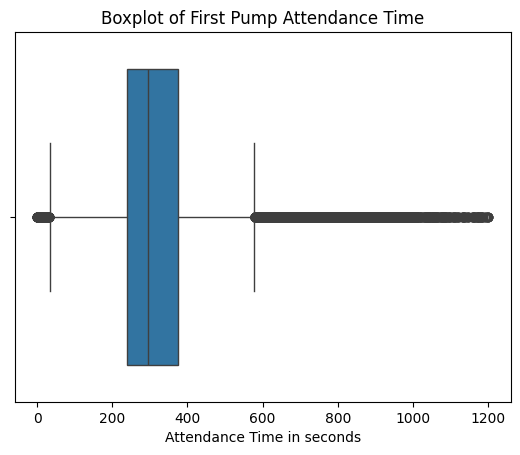

In [ ]:
# detect implausible values regarding response time
# drop missing values since they haven´t been replaced yet
no_nans = df.dropna(subset=["FirstPumpArriving_AttendanceTime"])

# create boxplot with seaborn
plt.figure()
sns.boxplot(x=no_nans["FirstPumpArriving_AttendanceTime"])
plt.title("Boxplot of First Pump Attendance Time")
plt.xlabel("Attendance Time in seconds")
plt.show()

# Missing Values & Duplicates

## Detect Missing Values

In [ ]:
# calculate sum of missing values
missing = df.isna().sum()

# percentage of missing values
missing_pct = df.isna().mean() * 100

# combine into one table
missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage (%)": missing_pct
})

# keep only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

display(missing_summary)

,Missing Values,Missing Percentage (%)
FirstPumpArriving_AttendanceTime,6018,6.455004
FirstPumpArriving_DeployedFromStation,6018,6.455004
NumCalls,27,0.028961
ResourceMobilisationId,13724,14.720584
PerformanceReporting,13724,14.720584
DateAndTimeMobilised,13724,14.720584
DateAndTimeMobile,14296,15.334120
DateAndTimeArrived,13724,14.720584
TurnoutTimeSeconds,14297,15.335193
TravelTimeSeconds,14304,15.342701


## Visualize NaNs

<Axes: >

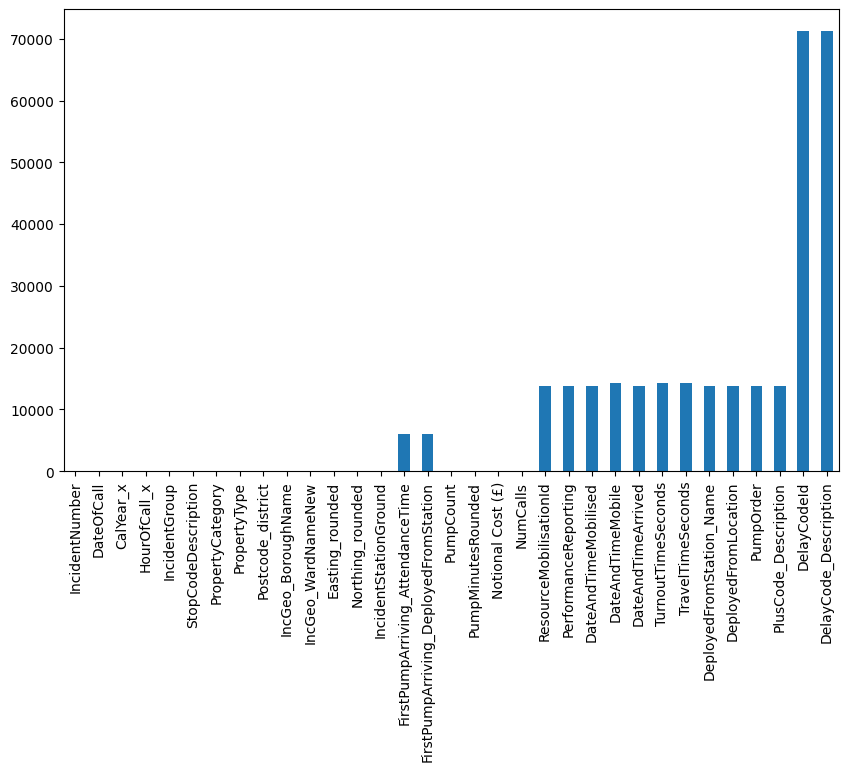

In [ ]:
# display bar plot to visualize missing values

plt.figure(figsize=(10,6))
df.isnull().sum().plot(kind="bar")

## Detect Duplicates

In [ ]:
# Number of duplicates
print("Number of duplicates:", df.duplicated().sum())

Number of duplicates: 0


In [ ]:
df.columns

Index(['IncidentNumber', 'DateOfCall', 'CalYear_x', 'HourOfCall_x',
       'IncidentGroup', 'StopCodeDescription', 'PropertyCategory',
       'PropertyType', 'Postcode_district', 'IncGeo_BoroughName',
       'IncGeo_WardNameNew', 'Easting_rounded', 'Northing_rounded',
       'IncidentStationGround', 'FirstPumpArriving_AttendanceTime',
       'FirstPumpArriving_DeployedFromStation', 'PumpCount',
       'PumpMinutesRounded', 'Notional Cost (£)', 'NumCalls',
       'ResourceMobilisationId', 'PerformanceReporting',
       'DateAndTimeMobilised', 'DateAndTimeMobile', 'DateAndTimeArrived',
       'TurnoutTimeSeconds', 'TravelTimeSeconds', 'DeployedFromStation_Name',
       'DeployedFromLocation', 'PumpOrder', 'PlusCode_Description',
       'DelayCodeId', 'DelayCode_Description'],
      dtype='object')

#

# Modification

## Fill NaNs

In [ ]:
# Replace "NULL" with 0 in DelayCodeId column
df.loc[:, "DelayCodeId"] = df["DelayCodeId"].fillna(0)

# Replace "NULL" with 'No Delay' in DelayCode_Description column
df.loc[:, "DelayCode_Description"] = df["DelayCode_Description"].fillna("No Delay")

# "DelayCodeId" column should be an integer:
df.loc[:,"DelayCodeId"] = df["DelayCodeId"].fillna(0).astype("Int64")

# Final overview after data conversion:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93230 entries, 14 to 976815
Data columns (total 33 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   IncidentNumber                         93230 non-null  object 
 1   DateOfCall                             93230 non-null  object 
 2   CalYear_x                              93230 non-null  int64  
 3   HourOfCall_x                           93230 non-null  int64  
 4   IncidentGroup                          93230 non-null  object 
 5   StopCodeDescription                    93230 non-null  object 
 6   PropertyCategory                       93230 non-null  object 
 7   PropertyType                           93230 non-null  object 
 8   Postcode_district                      93230 non-null  object 
 9   IncGeo_BoroughName                     93230 non-null  object 
 10  IncGeo_WardNameNew                     93230 non-null  object 
 11  Easti

In [ ]:
# drop rows altough NaNs > 0.05% but it is the target variable.
# Imputing would create artifical values and therefore would distort analysis

df = df.dropna(subset=["FirstPumpArriving_AttendanceTime"])

## Data Type

In [ ]:
# Convert Date and Time columns from object to dateime format

date_cols = [
    "DateOfCall",
    "DateAndTimeMobilised",
    "DateAndTimeMobile",
    "DateAndTimeArrived"
]

for col in date_cols:
    df[col] = pd.to_datetime(
        df[col],
        format="mixed",
        errors="coerce",
        dayfirst=True
    )

In [ ]:
# select all columns with data type object
object_cols = df.select_dtypes(include=["object"]).columns

# convert to string
df[object_cols] = df[object_cols].astype("string")

In [ ]:
# Column NumCalls: convert from float to integer
df["NumCalls"] = df["NumCalls"].astype("Int64")

## Rename Columns

In [ ]:
# show column names
df.columns

Index(['IncidentNumber', 'DateOfCall', 'CalYear_x', 'HourOfCall_x',
       'IncidentGroup', 'StopCodeDescription', 'PropertyCategory',
       'PropertyType', 'Postcode_district', 'IncGeo_BoroughName',
       'IncGeo_WardNameNew', 'Easting_rounded', 'Northing_rounded',
       'IncidentStationGround', 'FirstPumpArriving_AttendanceTime',
       'FirstPumpArriving_DeployedFromStation', 'PumpCount',
       'PumpMinutesRounded', 'Notional Cost (£)', 'NumCalls',
       'ResourceMobilisationId', 'PerformanceReporting',
       'DateAndTimeMobilised', 'DateAndTimeMobile', 'DateAndTimeArrived',
       'TurnoutTimeSeconds', 'TravelTimeSeconds', 'DeployedFromStation_Name',
       'DeployedFromLocation', 'PumpOrder', 'PlusCode_Description',
       'DelayCodeId', 'DelayCode_Description'],
      dtype='object')

In [ ]:
# rename columns for better readability / understanding

df = df.rename(columns={
    "CalYear_x" : "Year",
    "HourOfCall_x" : "HourOfCall",
    "IncGeo_BoroughName" : "BoroughName",
    "IncGeo_WardNameNew" : "WardName"
})

#

# Final Summary Table

In [ ]:
# create summary table
summary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isna().sum().values,
    "Missing (%)": (df.isna().sum().values / len(df) * 100).round(2),
    "Unique Values": df.nunique().values
})

# sort by missing values
summary = summary.sort_values(by="Missing (%)", ascending=False)

# reset index
summary = summary.reset_index(drop=True)

# display dataset shape
rows, cols = df.shape
print(f"Dataset Shape: {rows} rows × {cols} columns\n")

# display table nicely
display(summary)



Dataset Shape: 93230 rows × 33 columns



,Column Name,Data Type,Missing Values,Missing (%),Unique Values
0,TurnoutTimeSeconds,float64,14297,15.34,439
1,TravelTimeSeconds,float64,14304,15.34,1036
2,DateAndTimeMobile,datetime64[ns],14296,15.33,78603
3,DeployedFromLocation,string[python],13780,14.78,2
4,PlusCode_Description,string[python],13724,14.72,1
5,DateAndTimeMobilised,datetime64[ns],13724,14.72,79168
6,PerformanceReporting,float64,13724,14.72,1
7,ResourceMobilisationId,float64,13724,14.72,79506
8,DateAndTimeArrived,datetime64[ns],13724,14.72,79184
9,PumpOrder,float64,13724,14.72,1


#

# Save data

In [ ]:
df.to_csv("/content/drive/MyDrive/Project London Fire Brigade/Final Report/df_Final_NEW.csv", index = False)

#

# Visualization

## Preparation

In [ ]:
# add column for mobilisation is true or false
df["HasMobilisation"] = df["ResourceMobilisationId"].notna()
df["HasMobilisation"].value_counts()


,count
HasMobilisation,
True,79506
False,13724


In [ ]:
# filter only rows where HasMobilisation euqals True and create copy for further processing
df_has_mobilisation = df.loc[(df["HasMobilisation"] == True)].copy()

In [ ]:
# create column to indicate whethere the 6 min service level agreement was met or not
df_has_mobilisation["Met_6min"] = (df["FirstPumpArriving_AttendanceTime"] <= 360).astype(int)

In [ ]:
df_has_mobilisation.to_csv("/content/drive/MyDrive/Project London Fire Brigade/Final Report/df_has_mobilisation.csv", index = False)

In [ ]:
# create column for weekday for temporal analysis
df_has_mobilisation["Weekday"] = df_has_mobilisation["DateOfCall"].dt.day_name()
# ordered weekday
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

## Distribution Target Variable

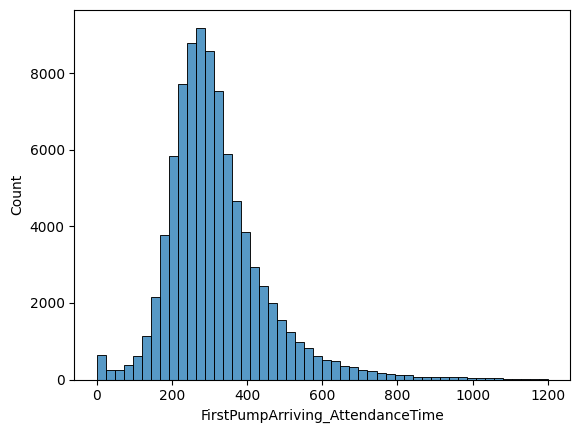

In [ ]:
# create histogram
sns.histplot(no_nans["FirstPumpArriving_AttendanceTime"], bins=50)
plt.show()

## Compliance Rate Westminster vs. Havering


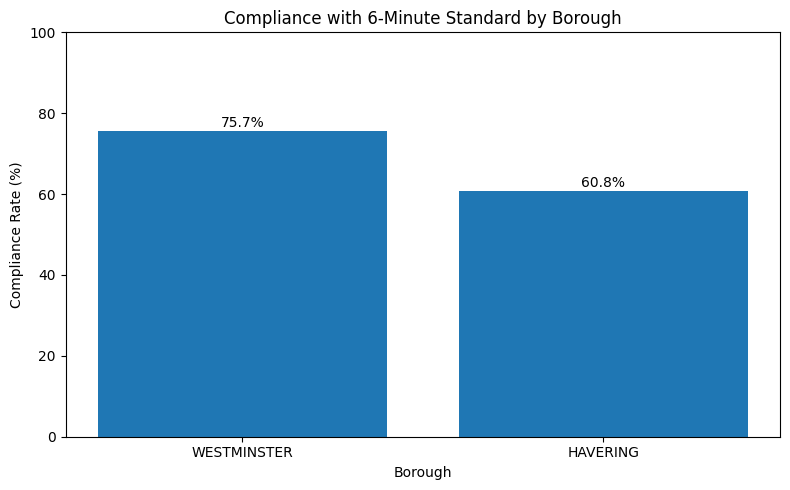

In [ ]:
# Calculate compliance rate (percentage of incidents within 6 minutes)
compliance = (
    df_has_mobilisation
    .groupby("BoroughName")["Met_6min"]  # group by borough
    .mean()                              # compute share of incidents meeting target
    .sort_values(ascending=False)        # sort from best to worst
    * 100                                # convert to percentage
)

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(compliance.index, compliance.values)

# Add titles and labels
plt.title("Compliance with 6-Minute Standard by Borough")
plt.xlabel("Borough")
plt.ylabel("Compliance Rate (%)")
plt.ylim(0, 100)

# Add percentage labels on top of each bar
for i, v in enumerate(compliance.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

# Improve layout and display plot
plt.tight_layout()
plt.show()

## Response Time by Borough

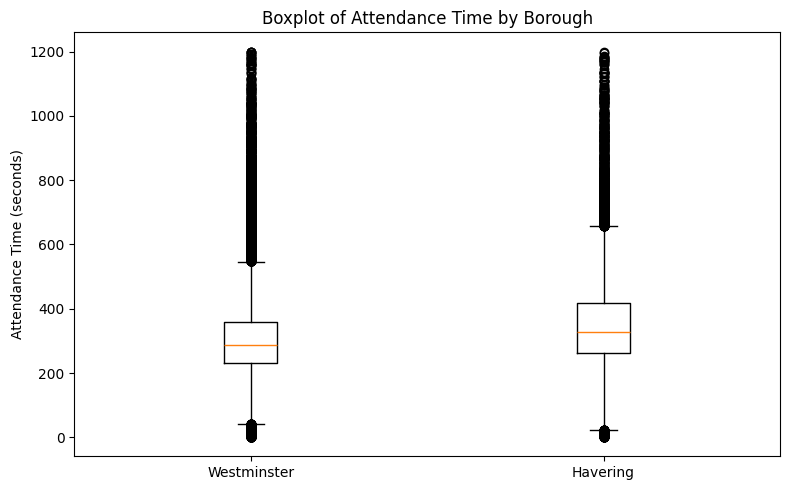

In [ ]:
# Extract response time data for each borough
westminster = df_has_mobilisation[
    df_has_mobilisation["BoroughName"] == "WESTMINSTER"
]["FirstPumpArriving_AttendanceTime"].dropna()

havering = df_has_mobilisation[
    df_has_mobilisation["BoroughName"] == "HAVERING"
]["FirstPumpArriving_AttendanceTime"].dropna()

# Create boxplot comparing both boroughs
plt.figure(figsize=(8, 5))
plt.boxplot(
    [westminster, havering],               # data for both groups
    tick_labels=["Westminster", "Havering"]  # x-axis labels
)

# Add title and axis label
plt.title("Boxplot of Attendance Time by Borough")
plt.ylabel("Attendance Time (seconds)")

# Adjust layout and display plot
plt.tight_layout()
plt.show()

## Distribution of Response Time

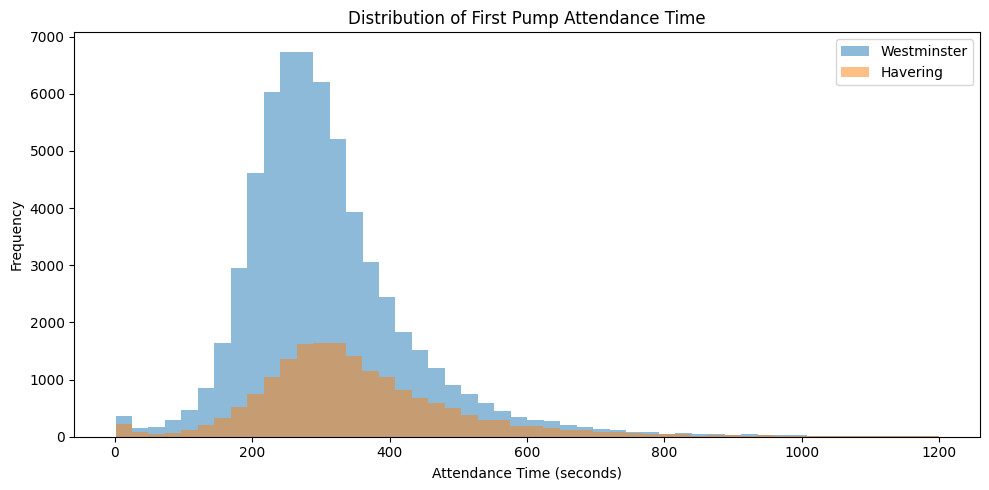

In [ ]:
# Create a figure with a defined size (width=10, height=5)
plt.figure(figsize=(10, 5))

# Filter response time data for Westminster and remove missing values
westminster = df_has_mobilisation[
    df_has_mobilisation["BoroughName"] == "WESTMINSTER"
]["FirstPumpArriving_AttendanceTime"].dropna()

# Filter response time data for Havering and remove missing values
havering = df_has_mobilisation[
    df_has_mobilisation["BoroughName"] == "HAVERING"
]["FirstPumpArriving_AttendanceTime"].dropna()

# Plot histogram for Westminster
# bins=50 controls the resolution of the histogram
# alpha=0.5 makes the bars semi-transparent so both distributions are visible
plt.hist(westminster, bins=50, alpha=0.5, label="Westminster")

# Plot histogram for Havering (overlaid with Westminster)
plt.hist(havering, bins=50, alpha=0.5, label="Havering")

# Add title and axis labels for clarity
plt.title("Distribution of First Pump Attendance Time")
plt.xlabel("Attendance Time (seconds)")
plt.ylabel("Frequency")

# Add legend to distinguish between the two boroughs
plt.legend()

# Adjust layout to prevent overlapping labels
plt.tight_layout()

# Display the plot
plt.show()

## Days-of-Week Analysis

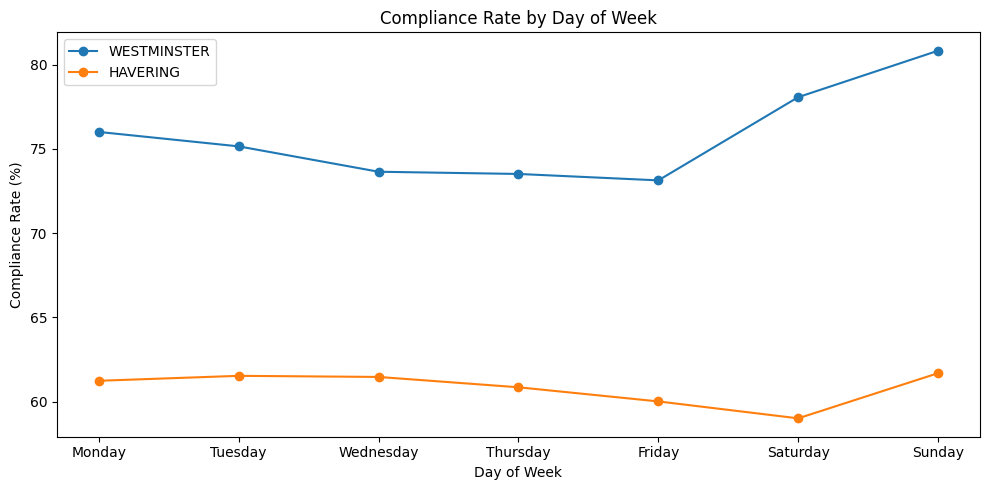

In [ ]:
weekday_compliance = (
    df_has_mobilisation.groupby(["Weekday", "BoroughName"])["Met_6min"]
    .mean()
    .reset_index()
)

weekday_compliance["Weekday"] = pd.Categorical(
    weekday_compliance["Weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_compliance = weekday_compliance.sort_values("Weekday")

plt.figure(figsize=(10, 5))

for borough in ["WESTMINSTER", "HAVERING"]:
    subset = weekday_compliance[weekday_compliance["BoroughName"] == borough]
    plt.plot(subset["Weekday"], subset["Met_6min"] * 100, marker="o", label=borough)

plt.title("Compliance Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Compliance Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

## Time-Based Demand Patterns (When incidents happen)

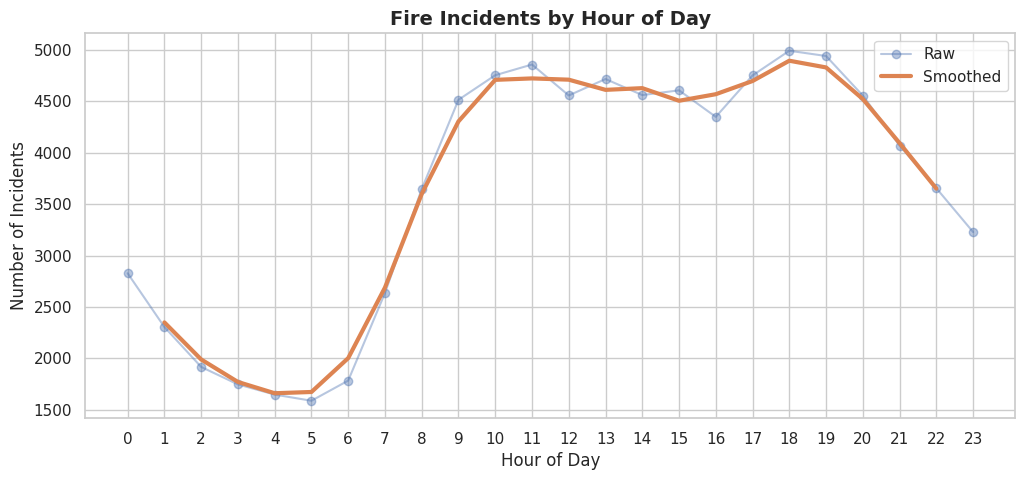

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Hourly counts
hourly = df.groupby("HourOfCall")["IncidentNumber"].count()

# Smooth with rolling mean
hourly_smooth = hourly.rolling(window=3, center=True).mean()

plt.figure(figsize=(12,5))
plt.plot(hourly.index, hourly.values, marker="o", alpha=0.4, label="Raw")
plt.plot(hourly.index, hourly_smooth, linewidth=3, label="Smoothed")

plt.title("Fire Incidents by Hour of Day", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Incidents")
plt.xticks(range(0,24))
plt.legend()
plt.show()

## Heatmap: Hour vs Incident Group

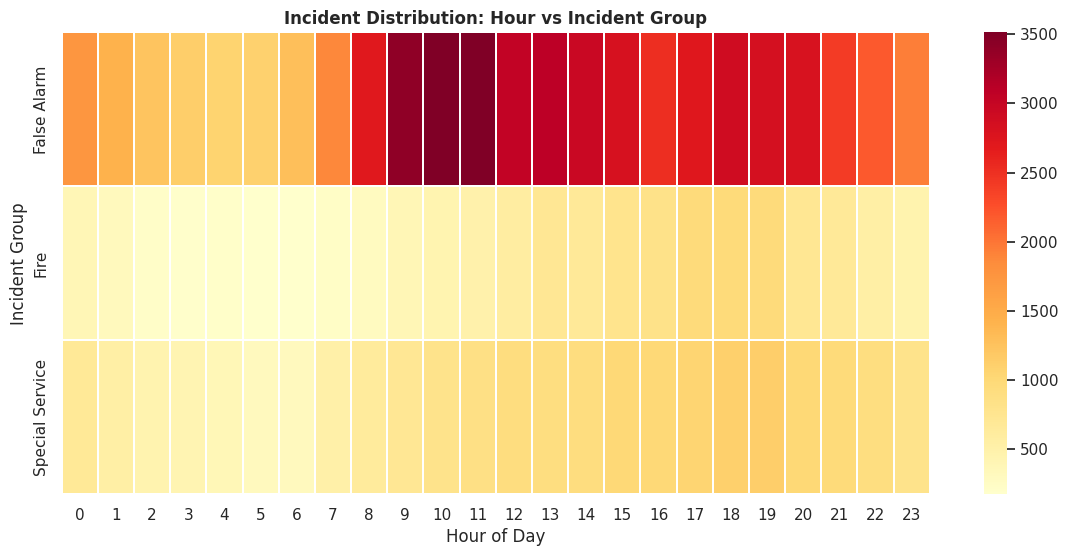

In [ ]:
heat_data = df.pivot_table(
    index="IncidentGroup",
    columns="HourOfCall",
    values="IncidentNumber",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(14,6))
sns.heatmap(heat_data, cmap="YlOrRd", linewidths=0.3)

plt.title("Incident Distribution: Hour vs Incident Group", fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Incident Group")
plt.show()

## 6-Minute Target KPI

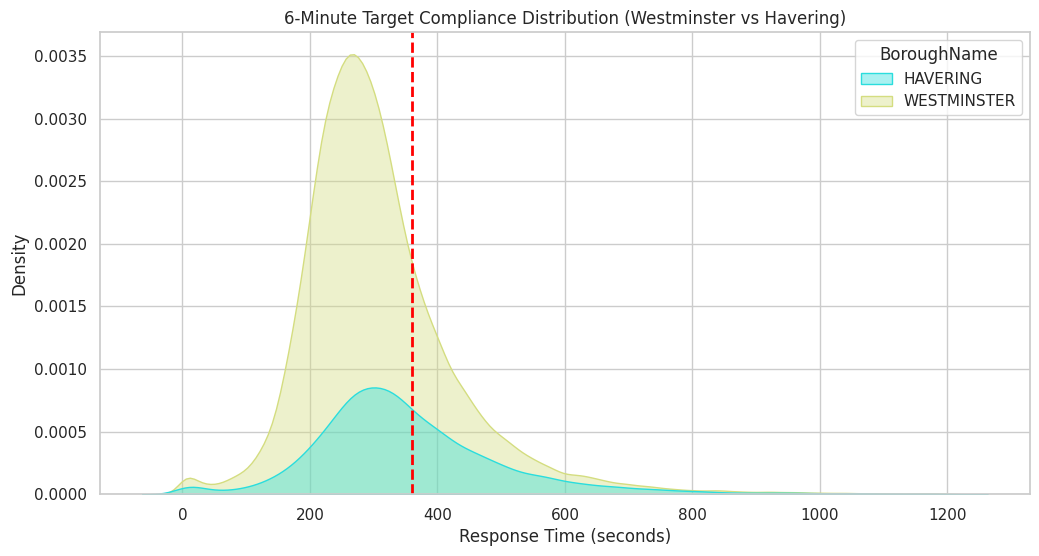

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_sub = df[df["BoroughName"].isin(["WESTMINSTER", "HAVERING"])].copy()

target = 360

sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

# KDE plots
sns.kdeplot(
    data=df_sub,
    x="FirstPumpArriving_AttendanceTime",
    hue="BoroughName",
    fill=True,
    palette="rainbow",
    alpha=0.4
)

# Target line
plt.axvline(target, color="red", linestyle="--", linewidth=2)

# --- Add borough labels (annotation) ---
west_mean = df_sub[df_sub["BoroughName"]=="WESTMINSTER"]["FirstPumpArriving_AttendanceTime"].mean()
hav_mean = df_sub[df_sub["BoroughName"]=="HAVERING"]["FirstPumpArriving_AttendanceTime"].mean()


plt.title("6-Minute Target Compliance Distribution (Westminster vs Havering)")
plt.xlabel("Response Time (seconds)")
plt.ylabel("Density")

plt.show()

## Yearly Trend Analysis

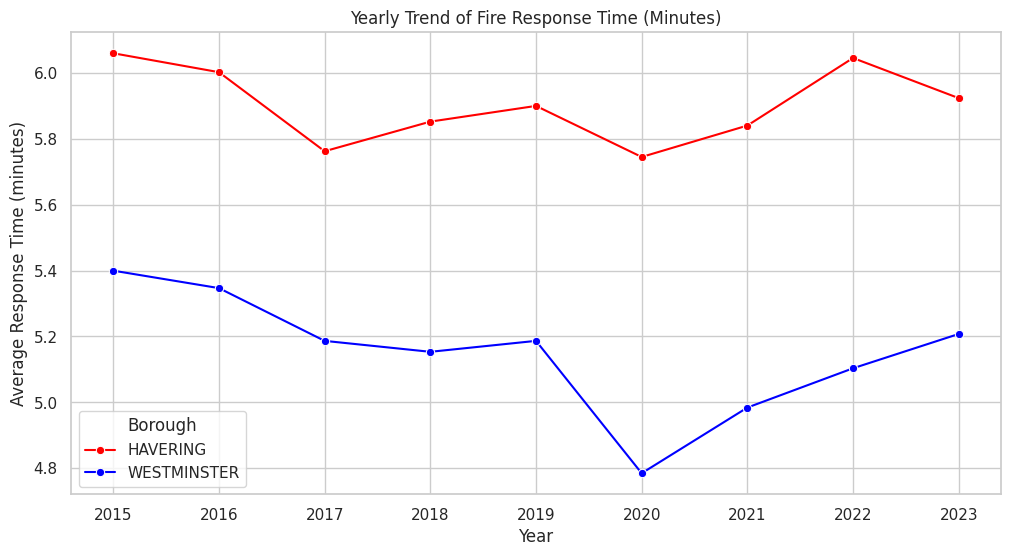

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_sub = df[df["BoroughName"].isin(["WESTMINSTER", "HAVERING"])].copy()

# Safe datetime handling
df_sub["DateOfCall"] = pd.to_datetime(df_sub["DateOfCall"], errors="coerce")
df_sub["Year"] = df_sub["DateOfCall"].dt.year

df_sub = df_sub.dropna(subset=["Year"])

# Convert seconds to minutes
df_sub["ResponseTime_Min"] = df_sub["FirstPumpArriving_AttendanceTime"] / 60

# Yearly aggregation
yearly = df_sub.groupby(["Year", "BoroughName"])["ResponseTime_Min"].mean().reset_index()

sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly,
    x="Year",
    y="ResponseTime_Min",
    hue="BoroughName",
    marker="o",
    palette=["red", "blue"]
)

plt.title("Yearly Trend of Fire Response Time (Minutes)")
plt.xlabel("Year")
plt.ylabel("Average Response Time (minutes)")
plt.legend(title="Borough")

plt.show()

#

# Save Final Data

In [ ]:
# save data set for further processing in Power BI
df.to_csv("/content/drive/MyDrive/Project London Fire Brigade/Final Report/df_final.csv", index = False)